# Analyze Extracted Skills (Multi-File Version)

**Memory-efficient analysis for large datasets**

Fixes:
1. Memory crash: processes files one by one instead of loading all
2. Divide by zero: handles empty skill_counter gracefully
3. IndexError on cumsum[-1]: checks for empty arrays before indexing
4. String-formatted lists: parses "['skill1']" strings to actual lists

## Step 1: Configuration

**Edit the path below to match your data location:**

In [45]:
# =============================================================================
# CONFIGURATION - EDIT THIS!
# =============================================================================

INPUT_FOLDER = '../data/extracted_skills_production'  # <-- Change this to your folder

# Column names (should match your parquet files)
SKILLS_COLUMN = 'skills'
NUM_SKILLS_COLUMN = 'num_skills'
BY_SECTION_COLUMN = 'by_section'
ONET_CODE_COLUMN = 'onet_code'
DATE_COLUMN = 'post_date'

# Columns to EXCLUDE when reading (to save memory)
# 'description' is the largest column and not needed for analysis
EXCLUDE_COLUMNS = ['description']

# Processing settings
FILES_PER_BATCH = 10  # Process N files at a time (for memory management)
TOP_N_SKILLS = 30

print(f"Input folder: {INPUT_FOLDER}")
print(f"Excluding columns: {EXCLUDE_COLUMNS}")

Input folder: ../data/extracted_skills_production
Excluding columns: ['description']


## Step 2: Imports and Helper Functions

In [46]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import json
import ast
import gc
from typing import List, Dict, Any
import pyarrow.parquet as pq  # for reading schema only (no data loaded)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print("✓ Imports successful")

✓ Imports successful


In [47]:
def parse_skills_column(value) -> List[str]:
    """
    Parse skills column that might be stored as string or list.
    
    Handles:
    - Already a list: ['skill1', 'skill2']
    - String representation: "['skill1', 'skill2']"
    - None/NaN
    - Empty list: []
    """
    if value is None:
        return []
    if isinstance(value, np.ndarray):
        return [str(s) for s in value if s is not None] 
    if isinstance(value, str):
        if value in ('[]', '', 'nan', 'None'):
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            pass
    return []


def parse_by_section_column(value) -> Dict[str, List[str]]:
    """Parse by_section column that might be stored as string or dict."""
    if value is None:
        return {}
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        if value in ('{}', '', 'nan', 'None'):
            return {}
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, dict):
                return parsed
        except (ValueError, SyntaxError):
            pass
    return {}


print("✓ Helper functions defined")

✓ Helper functions defined


## Step 3: Find and List Files

In [48]:
input_path = Path(INPUT_FOLDER)

if not input_path.exists():
    print(f"❌ Folder not found: {INPUT_FOLDER}")
    print(f"\nAbsolute path: {input_path.absolute()}")
    print("\nPlease update INPUT_FOLDER in Step 1.")
else:
    parquet_files = sorted(input_path.glob('*.parquet'))
    
    if not parquet_files:
        print(f"❌ No parquet files found in {INPUT_FOLDER}")
    else:
        print(f"✓ Found {len(parquet_files)} parquet files")
        print(f"\nFirst 5 files:")
        for f in parquet_files[:5]:
            size_mb = f.stat().st_size / 1024**2
            print(f"  - {f.name} ({size_mb:.1f} MB)")
        
        if len(parquet_files) > 5:
            print(f"  ... and {len(parquet_files) - 5} more files")
        
        total_size = sum(f.stat().st_size for f in parquet_files) / 1024**3
        print(f"\nTotal size: {total_size:.2f} GB")

✓ Found 279 parquet files

First 5 files:
  - part_rg_00000_skills.parquet (190.8 MB)
  - part_rg_00001_skills.parquet (191.6 MB)
  - part_rg_00002_skills.parquet (192.4 MB)
  - part_rg_00003_skills.parquet (192.7 MB)
  - part_rg_00004_skills.parquet (192.1 MB)
  ... and 274 more files

Total size: 51.91 GB


## Step 4: Check Data Format (Test with 1 File)

In [49]:
# Load first file to check format (excluding description column to save memory)
if parquet_files:
    test_file = parquet_files[0]
    print(f"Testing with: {test_file.name}\n")

    # Read only schema (no data loaded, instant)
    schema = pq.read_schema(test_file)
    all_cols = schema.names
    cols_to_read = [c for c in all_cols if c not in EXCLUDE_COLUMNS]
    print(f"Total columns: {len(all_cols)}, Loading: {len(cols_to_read)} (excluding {EXCLUDE_COLUMNS})")

    df_test = pd.read_parquet(test_file, columns=cols_to_read)

    print(f"Columns: {list(df_test.columns)}")
    print(f"Rows: {len(df_test):,}")

    # Check skills column format
    if SKILLS_COLUMN in df_test.columns:
        sample_value = df_test[SKILLS_COLUMN].iloc[0]
        print(f"\n{SKILLS_COLUMN} column:")
        print(f"  Type: {type(sample_value)}")
        print(f"  Sample: {sample_value}")

        # Test parsing
        parsed = parse_skills_column(sample_value)
        print(f"  Parsed: {parsed}")
        print(f"  Parsed type: {type(parsed)}")
    else:
        print(f"\n⚠️ Column '{SKILLS_COLUMN}' not found!")
        print(f"Available columns: {list(df_test.columns)}")

    # Free memory
    del df_test
    gc.collect()

Testing with: part_rg_00000_skills.parquet

Total columns: 45, Loading: 44 (excluding ['description'])
Columns: ['job_id', 'rcid', 'company', 'rics_k50', 'rics_k200', 'rics_k400', 'title_raw', 'title_translated', 'job_category', 'role_k50', 'role_k150', 'role_k300', 'role_k500', 'role_k1000', 'role_k1250', 'role_k1500', 'location_raw', 'region', 'country', 'state', 'metro_area', 'salary', 'post_date', 'remove_date', 'ultimate_parent_rcid', 'ultimate_parent_company_name', 'onet_code', 'onet_title', 'remote_type', 'expected_hires', 'jobtitle', 'source_company_sites', 'source_linkedin', 'source_indeed', 'source_zhaopin', 'source_51job', 'source_liepin', 'source_other_aggregators', 'salary_min', 'salary_max', 'salary_predicted', 'skills', 'num_skills', 'by_section']
Rows: 78,787

skills column:
  Type: <class 'numpy.ndarray'>
  Sample: ['Technology Design' 'Design' 'Administration and Management' 'Python'
 'Programming' 'Spatial Orientation']
  Parsed: ['Technology Design', 'Design', 'Admi

## Step 5: Process All Files (Memory Efficient)

This processes files one by one, extracting only statistics to save memory.

In [50]:
def process_single_file(filepath: Path) -> Dict[str, Any]:
    """Process a single parquet file and extract statistics."""
    try:
        # Read only schema (no data loaded, instant) then exclude large columns
        schema = pq.read_schema(filepath)
        all_cols = schema.names
        cols_to_read = [c for c in all_cols if c not in EXCLUDE_COLUMNS]
        df = pd.read_parquet(filepath, columns=cols_to_read)
    except Exception as e:
        print(f"    Error reading {filepath.name}: {e}")
        return None

    stats = {
        'filepath': str(filepath),
        'num_rows': len(df),
        'skill_counter': Counter(),
        'section_counts': {},
        'section_jd_counts': {},
        'num_skills_list': [],
        'onet_counts': Counter(),
        'jds_with_skills': 0,
        'jds_without_skills': 0,
    }

    # Process skills column
    if SKILLS_COLUMN in df.columns:
        for idx, row in df.iterrows():
            skills = parse_skills_column(row.get(SKILLS_COLUMN))
            num_skills = len(skills)

            stats['num_skills_list'].append(num_skills)
            stats['skill_counter'].update(skills)

            if num_skills > 0:
                stats['jds_with_skills'] += 1
            else:
                stats['jds_without_skills'] += 1

    # Process by_section column
    if BY_SECTION_COLUMN in df.columns:
        for idx, row in df.iterrows():
            by_section = parse_by_section_column(row.get(BY_SECTION_COLUMN))
            for section, skills in by_section.items():
                # Initialize dict key first
                if section not in stats['section_counts']:
                    stats['section_counts'][section] = 0
                    stats['section_jd_counts'][section] = 0

                # Handle None or invalid skills values
                if skills is None:
                    continue
                if isinstance(skills, np.ndarray):
                    skills = skills.tolist()
                if not isinstance(skills, (list, tuple)):
                    continue

                stats['section_counts'][section] += len(skills)
                stats['section_jd_counts'][section] += 1

    # Process ONET column
    if ONET_CODE_COLUMN in df.columns:
        stats['onet_counts'].update(df[ONET_CODE_COLUMN].dropna().tolist())



    return stats

print("✓ Processing function defined (excluding description column)")

✓ Processing function defined (excluding description column)


In [51]:
# Process all files
print("="*70)
print("PROCESSING ALL FILES")
print("="*70)

all_stats = []

for i, filepath in enumerate(parquet_files):
    print(f"[{i+1}/{len(parquet_files)}] Processing {filepath.name}...", end=" ")
    stats = process_single_file(filepath)
    
    if stats:
        all_stats.append(stats)
        print(f"OK ({stats['num_rows']:,} rows, {stats['jds_with_skills']:,} with skills)")
    else:
        print("FAILED")
    
    # Periodic memory cleanup
    if (i + 1) % FILES_PER_BATCH == 0:
        gc.collect()

print(f"\n✓ Processed {len(all_stats)}/{len(parquet_files)} files successfully")

PROCESSING ALL FILES
[1/279] Processing part_rg_00000_skills.parquet... OK (78,787 rows, 74,793 with skills)
[2/279] Processing part_rg_00001_skills.parquet... OK (78,623 rows, 74,870 with skills)
[3/279] Processing part_rg_00002_skills.parquet... OK (79,129 rows, 75,004 with skills)
[4/279] Processing part_rg_00003_skills.parquet... OK (79,439 rows, 75,237 with skills)
[5/279] Processing part_rg_00004_skills.parquet... OK (79,176 rows, 75,096 with skills)
[6/279] Processing part_rg_00005_skills.parquet... OK (78,921 rows, 74,875 with skills)
[7/279] Processing part_rg_00006_skills.parquet... OK (79,008 rows, 74,998 with skills)
[8/279] Processing part_rg_00007_skills.parquet... OK (78,761 rows, 74,629 with skills)
[9/279] Processing part_rg_00008_skills.parquet... OK (79,060 rows, 74,916 with skills)
[10/279] Processing part_rg_00009_skills.parquet... OK (78,925 rows, 74,787 with skills)
[11/279] Processing part_rg_00010_skills.parquet... OK (78,893 rows, 74,732 with skills)
[12/279] 

## Step 6: Merge Statistics

In [52]:
# Merge all statistics
merged = {
    'total_rows': 0,
    'total_files': len(all_stats),
    'skill_counter': Counter(),
    'section_counts': {},
    'section_jd_counts': {},
    'all_num_skills': [],
    'onet_counts': Counter(),
    'jds_with_skills': 0,
    'jds_without_skills': 0,
}

for stats in all_stats:
    if stats is None:
        continue
    
    merged['total_rows'] += stats['num_rows']
    merged['skill_counter'].update(stats['skill_counter'])
    merged['onet_counts'].update(stats['onet_counts'])
    merged['all_num_skills'].extend(stats['num_skills_list'])
    merged['jds_with_skills'] += stats['jds_with_skills']
    merged['jds_without_skills'] += stats['jds_without_skills']
    
    for section, count in stats['section_counts'].items():
        if section not in merged['section_counts']:
            merged['section_counts'][section] = 0
            merged['section_jd_counts'][section] = 0
        merged['section_counts'][section] += count
        merged['section_jd_counts'][section] += stats['section_jd_counts'].get(section, 0)



print("✓ Statistics merged")
print(f"  Total JDs: {merged['total_rows']:,}")
print(f"  Unique skills: {len(merged['skill_counter']):,}")

✓ Statistics merged
  Total JDs: 21,935,789
  Unique skills: 2,219


## Step 7: Overall Statistics

In [53]:
print("="*70)
print("OVERALL STATISTICS")
print("="*70)

print(f"\nTotal files processed: {merged['total_files']}")
print(f"Total job descriptions: {merged['total_rows']:,}")

if merged['total_rows'] > 0:
    pct_with = merged['jds_with_skills'] / merged['total_rows'] * 100
    pct_without = merged['jds_without_skills'] / merged['total_rows'] * 100
    print(f"JDs with skills: {merged['jds_with_skills']:,} ({pct_with:.1f}%)")
    print(f"JDs without skills: {merged['jds_without_skills']:,} ({pct_without:.1f}%)")

# Skills per JD statistics
num_skills_arr = np.array(merged['all_num_skills'])
if len(num_skills_arr) > 0:
    print(f"\nSkills per Job Description:")
    print(f"  Mean:   {np.mean(num_skills_arr):.1f}")
    print(f"  Median: {np.median(num_skills_arr):.1f}")
    print(f"  Std:    {np.std(num_skills_arr):.1f}")
    print(f"  Min:    {np.min(num_skills_arr):.0f}")
    print(f"  Max:    {np.max(num_skills_arr):.0f}")

# Unique skills
skill_counter = merged['skill_counter']
if skill_counter:
    unique_skills = len(skill_counter)
    total_mentions = sum(skill_counter.values())
    print(f"\nSkill diversity:")
    print(f"  Total unique skills: {unique_skills:,}")
    print(f"  Total skill mentions: {total_mentions:,}")
    if unique_skills > 0:
        print(f"  Avg mentions per skill: {total_mentions/unique_skills:.1f}")
else:
    print("\n⚠️ No skills found in the data!")

OVERALL STATISTICS

Total files processed: 279
Total job descriptions: 21,935,789
JDs with skills: 20,793,164 (94.8%)
JDs without skills: 1,142,625 (5.2%)

Skills per Job Description:
  Mean:   8.4
  Median: 8.0
  Std:    5.7
  Min:    0
  Max:    141

Skill diversity:
  Total unique skills: 2,219
  Total skill mentions: 184,736,336
  Avg mentions per skill: 83252.1


## Step 8: Top Skills

In [54]:
print("="*70)
print(f"TOP {TOP_N_SKILLS} MOST COMMON SKILLS")
print("="*70)

if skill_counter:
    top_skills = skill_counter.most_common(TOP_N_SKILLS)
    
    print(f"\n{'Rank':<6}{'Skill':<50}{'Count':>10}{'% of JDs':>12}")
    print("-"*78)
    
    for rank, (skill, count) in enumerate(top_skills, 1):
        pct = (count / merged['total_rows']) * 100 if merged['total_rows'] > 0 else 0
        print(f"{rank:<6}{skill[:48]:<50}{count:>10,}{pct:>11.1f}%")
else:
    print("\n⚠️ No skills found!")
    print("Possible causes:")
    print("  1. Skills column contains strings instead of lists")
    print("  2. Skills column is empty")
    print("  3. Column name mismatch (check SKILLS_COLUMN setting)")

TOP 30 MOST COMMON SKILLS

Rank  Skill                                                  Count    % of JDs
------------------------------------------------------------------------------
1     Administration and Management                     11,731,607       53.5%
2     Spatial Orientation                                9,960,794       45.4%
3     Education and Training                             6,962,760       31.7%
4     Sales and Marketing                                6,689,919       30.5%
5     Building and Construction                          5,862,766       26.7%
6     Operations Analysis                                4,818,509       22.0%
7     Customer and Personal Service                      4,718,548       21.5%
8     Design                                             4,607,210       21.0%
9     ComplianceMAX                                      4,414,183       20.1%
10    Engineering and Technology                         3,296,128       15.0%
11    Science            

## Step 9: Skills by Section

In [55]:
print("="*70)
print("SKILLS BY SECTION")
print("="*70)

section_counts = merged['section_counts']

if section_counts:
    total_section_skills = sum(section_counts.values())
    
    print(f"\n{'Section':<30}{'Total Skills':>15}{'% of Total':>12}")
    print("-"*57)
    
    for section in sorted(section_counts.keys(), key=lambda x: section_counts[x], reverse=True):
        count = section_counts[section]
        pct = (count / total_section_skills * 100) if total_section_skills > 0 else 0
        print(f"{section:<30}{count:>15,}{pct:>11.1f}%")
else:
    print("\n[INFO] No section data available")

SKILLS BY SECTION

Section                          Total Skills  % of Total
---------------------------------------------------------
Technology Skills                  73,799,224       39.9%
Knowledge                          68,369,118       37.0%
Skills                             26,544,315       14.4%
Abilities                          16,023,679        8.7%


## Step 10: Visualizations

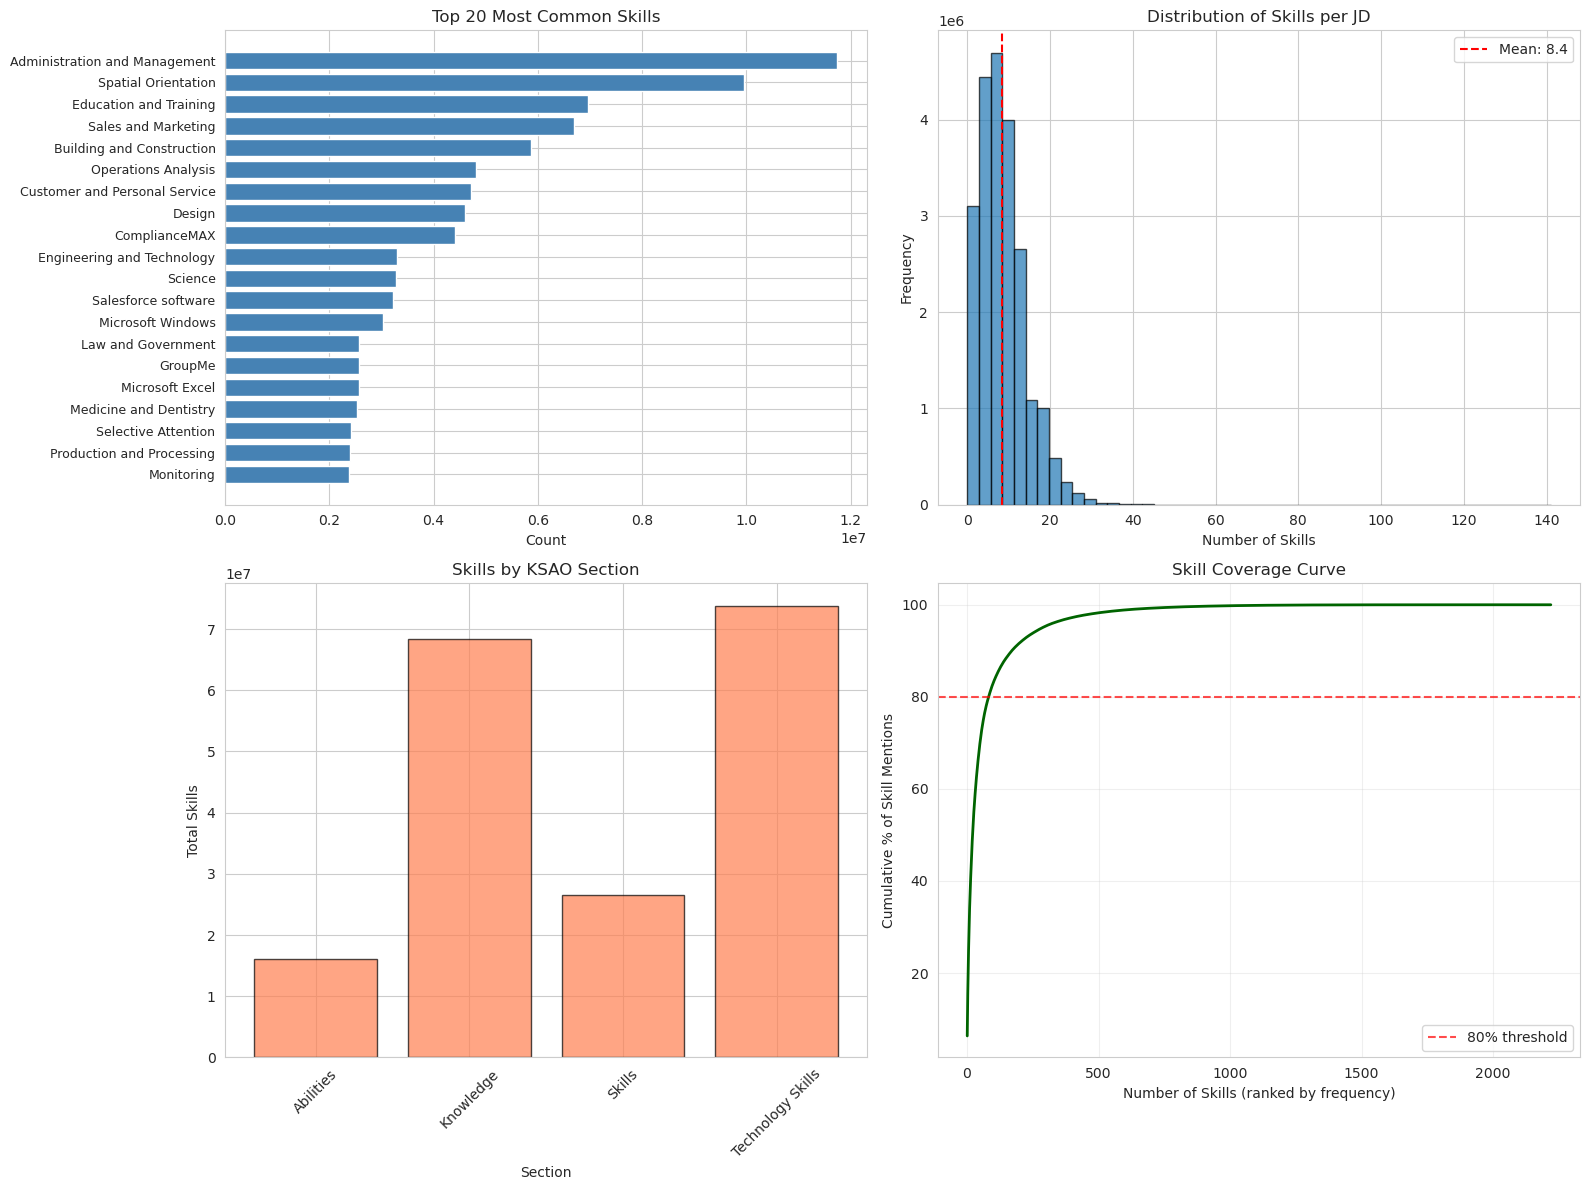

In [56]:
if skill_counter:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Top skills bar chart
    top_20 = skill_counter.most_common(20)
    if top_20:
        skills_names = [s[0][:40] for s in top_20]  # Truncate long names
        skills_counts = [s[1] for s in top_20]
        
        axes[0, 0].barh(range(len(skills_names)), skills_counts, color='steelblue')
        axes[0, 0].set_yticks(range(len(skills_names)))
        axes[0, 0].set_yticklabels(skills_names, fontsize=9)
        axes[0, 0].set_xlabel('Count')
        axes[0, 0].set_title('Top 20 Most Common Skills')
        axes[0, 0].invert_yaxis()
    
    # Plot 2: Skills per JD histogram
    if len(num_skills_arr) > 0:
        axes[0, 1].hist(num_skills_arr, bins=50, edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(np.mean(num_skills_arr), color='red', linestyle='--', 
                           label=f'Mean: {np.mean(num_skills_arr):.1f}')
        axes[0, 1].set_xlabel('Number of Skills')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Distribution of Skills per JD')
        axes[0, 1].legend()
    
    # Plot 3: Skills by section
    if section_counts:
        sections = list(section_counts.keys())
        counts = [section_counts[s] for s in sections]
        
        axes[1, 0].bar(sections, counts, color='coral', edgecolor='black', alpha=0.7)
        axes[1, 0].set_xlabel('Section')
        axes[1, 0].set_ylabel('Total Skills')
        axes[1, 0].set_title('Skills by KSAO Section')
        axes[1, 0].tick_params(axis='x', rotation=45)
    else:
        axes[1, 0].text(0.5, 0.5, 'No section data', ha='center', va='center')
    
    # Plot 4: Cumulative skill coverage (FIXED - handles empty data)
    sorted_counts = sorted(skill_counter.values(), reverse=True)
    if sorted_counts:
        cumsum = np.cumsum(sorted_counts)
        cumsum_pct = (cumsum / cumsum[-1]) * 100
        
        axes[1, 1].plot(range(1, len(cumsum_pct) + 1), cumsum_pct, 
                       color='darkgreen', linewidth=2)
        axes[1, 1].axhline(80, color='red', linestyle='--', alpha=0.7, 
                           label='80% threshold')
        axes[1, 1].set_xlabel('Number of Skills (ranked by frequency)')
        axes[1, 1].set_ylabel('Cumulative % of Skill Mentions')
        axes[1, 1].set_title('Skill Coverage Curve')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'No data available', ha='center', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Cannot generate plots - no skill data available")

正在收集季度数据...
  [20/279]
  [40/279]
  [60/279]
  [80/279]
  [100/279]
  [120/279]
  [140/279]
  [160/279]
  [180/279]
  [200/279]
  [220/279]
  [240/279]
  [260/279]
✓ 完成，共 53 个季度


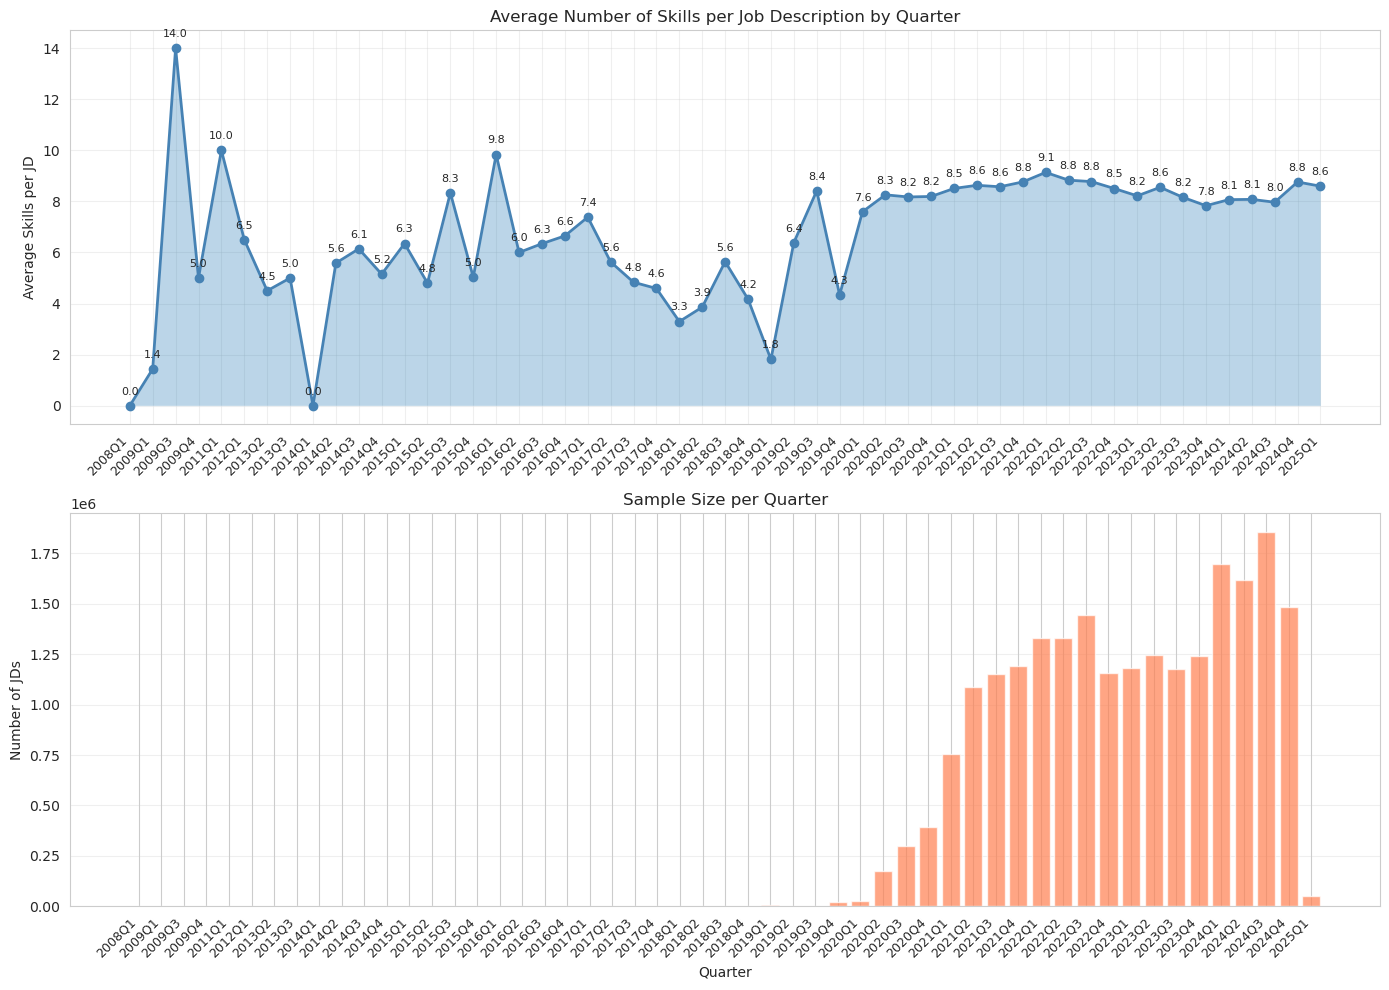


Quarter       Avg Skills    JD Count
------------------------------------
2008Q1              0.00           1
2009Q1              1.44          16
2009Q3             14.00           1
2009Q4              5.00           7
2011Q1             10.00           1
2012Q1              6.50           2
2013Q2              4.50           2
2013Q3              5.00           1
2014Q1              0.00           3
2014Q2              5.58          60
2014Q3              6.14          35
2014Q4              5.15          20
2015Q1              6.35          20
2015Q2              4.80          15
2015Q3              8.33           3
2015Q4              5.03          34
2016Q1              9.83           6
2016Q2              6.00           9
2016Q3              6.34       3,729
2016Q4              6.65         288
2017Q1              7.38          81
2017Q2              5.63         248
2017Q3              4.83         217
2017Q4              4.59         156
2018Q1              3.29         153


In [57]:
# ============================================================
# 季度平均 Skills 数量趋势图
# ============================================================

from collections import defaultdict

quarterly_stats = defaultdict(list)  # quarter -> list of num_skills

print("正在收集季度数据...")

for i, filepath in enumerate(parquet_files):
    if (i + 1) % 20 == 0:
        print(f"  [{i+1}/{len(parquet_files)}]")

    try:
        # 只读取需要的两列
        df = pd.read_parquet(filepath, columns=[DATE_COLUMN, SKILLS_COLUMN])
    except Exception:
        continue

    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors='coerce')
    df['quarter'] = df[DATE_COLUMN].dt.to_period('Q')

    for idx, row in df.iterrows():
        q = row['quarter']
        if pd.isna(q):
            continue
        skills = parse_skills_column(row.get(SKILLS_COLUMN))
        quarterly_stats[str(q)].append(len(skills))


print(f"✓ 完成，共 {len(quarterly_stats)} 个季度")

# 计算统计
quarters = sorted(quarterly_stats.keys())
avg_skills = [np.mean(quarterly_stats[q]) for q in quarters]
counts = [len(quarterly_stats[q]) for q in quarters]

# 绘图
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 上图：平均 skills 折线图
axes[0].plot(quarters, avg_skills, marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(range(len(quarters)), avg_skills, alpha=0.3)
axes[0].set_ylabel('Average Skills per JD')
axes[0].set_title('Average Number of Skills per Job Description by Quarter')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(quarters)))
axes[0].set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)

for i, v in enumerate(avg_skills):
    axes[0].annotate(f'{v:.1f}', (i, v), textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=8)

# 下图：样本量
axes[1].bar(quarters, counts, color='coral', alpha=0.7)
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Number of JDs')
axes[1].set_title('Sample Size per Quarter')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(range(len(quarters)))
axes[1].set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

# 打印数据表
print(f"\n{'Quarter':<12}{'Avg Skills':>12}{'JD Count':>12}")
print("-"*36)
for q, avg, cnt in zip(quarters, avg_skills, counts):
    print(f"{q:<12}{avg:>12.2f}{cnt:>12,}")

Tracking: 'microsoft excel' across all files...
  [30/279]
  [60/279]
  [90/279]
  [120/279]
  [150/279]
  [180/279]
  [210/279]
  [240/279]
  [270/279]
✓ Done. Found data for 53 quarters.



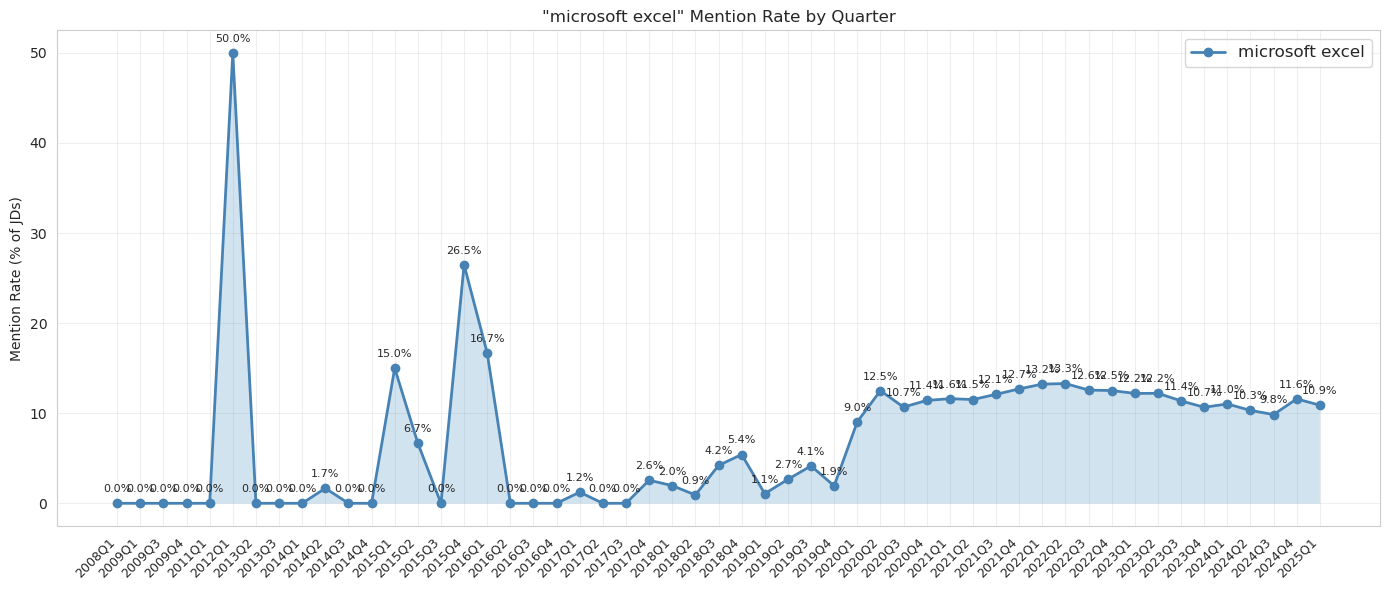

Quarter       Mention Rate  JDs w/ Skill   Total JDs
----------------------------------------------------
2008Q1               0.00%             0           1
2009Q1               0.00%             0          16
2009Q3               0.00%             0           1
2009Q4               0.00%             0           7
2011Q1               0.00%             0           1
2012Q1              50.00%             1           2
2013Q2               0.00%             0           2
2013Q3               0.00%             0           1
2014Q1               0.00%             0           3
2014Q2               1.67%             1          60
2014Q3               0.00%             0          35
2014Q4               0.00%             0          20
2015Q1              15.00%             3          20
2015Q2               6.67%             1          15
2015Q3               0.00%             0           3
2015Q4              26.47%             9          34
2016Q1              16.67%             1      

In [58]:
# =============================================================================
# SINGLE SKILL TREND - Edit the skill name below
# =============================================================================
TARGET_SKILL = 'microsoft excel'  # <-- Change this to any skill you want to track
# =============================================================================

from collections import defaultdict

# quarter -> {'total': N, 'with_skill': N}
quarterly_data = defaultdict(lambda: {'total': 0, 'with_skill': 0})

print(f"Tracking: '{TARGET_SKILL}' across all files...")

for i, filepath in enumerate(parquet_files):
    if (i + 1) % 30 == 0:
        print(f"  [{i+1}/{len(parquet_files)}]")

    try:
        df = pd.read_parquet(filepath, columns=[DATE_COLUMN, SKILLS_COLUMN])
    except Exception:
        continue

    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors='coerce')
    df['quarter'] = df[DATE_COLUMN].dt.to_period('Q')

    for _, row in df.iterrows():
        q = row['quarter']
        if pd.isna(q):
            continue
        q_str = str(q)
        quarterly_data[q_str]['total'] += 1

        skills = parse_skills_column(row.get(SKILLS_COLUMN))
        if TARGET_SKILL.lower() in [s.lower() for s in skills]:
            quarterly_data[q_str]['with_skill'] += 1


# Calculate mention rate
quarters = sorted(quarterly_data.keys())
mention_rates = []
for q in quarters:
    total = quarterly_data[q]['total']
    with_skill = quarterly_data[q]['with_skill']
    rate = (with_skill / total * 100) if total > 0 else 0
    mention_rates.append(rate)

print(f"✓ Done. Found data for {len(quarters)} quarters.\n")

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(quarters)), mention_rates, marker='o', linewidth=2,
        markersize=6, color='steelblue', label=TARGET_SKILL)
ax.fill_between(range(len(quarters)), mention_rates, alpha=0.2)
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mention Rate (% of JDs)')
ax.set_title(f'"{TARGET_SKILL}" Mention Rate by Quarter')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

for i, rate in enumerate(mention_rates):
    ax.annotate(f'{rate:.1f}%', (i, rate), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Print table
print(f"{'Quarter':<12}{'Mention Rate':>14}{'JDs w/ Skill':>14}{'Total JDs':>12}")
print("-" * 52)
for q in quarters:
    d = quarterly_data[q]
    rate = (d['with_skill'] / d['total'] * 100) if d['total'] > 0 else 0
    print(f"{q:<12}{rate:>13.2f}%{d['with_skill']:>14,}{d['total']:>12,}")

Tracking 4 skills: ['Python', 'mysql', 'oracle database', 'snowflake']
Scanning 279 files...

  [30/279]
  [60/279]
  [90/279]
  [120/279]
  [150/279]
  [180/279]
  [210/279]
  [240/279]
  [270/279]
✓ Done. Found data for 53 quarters.



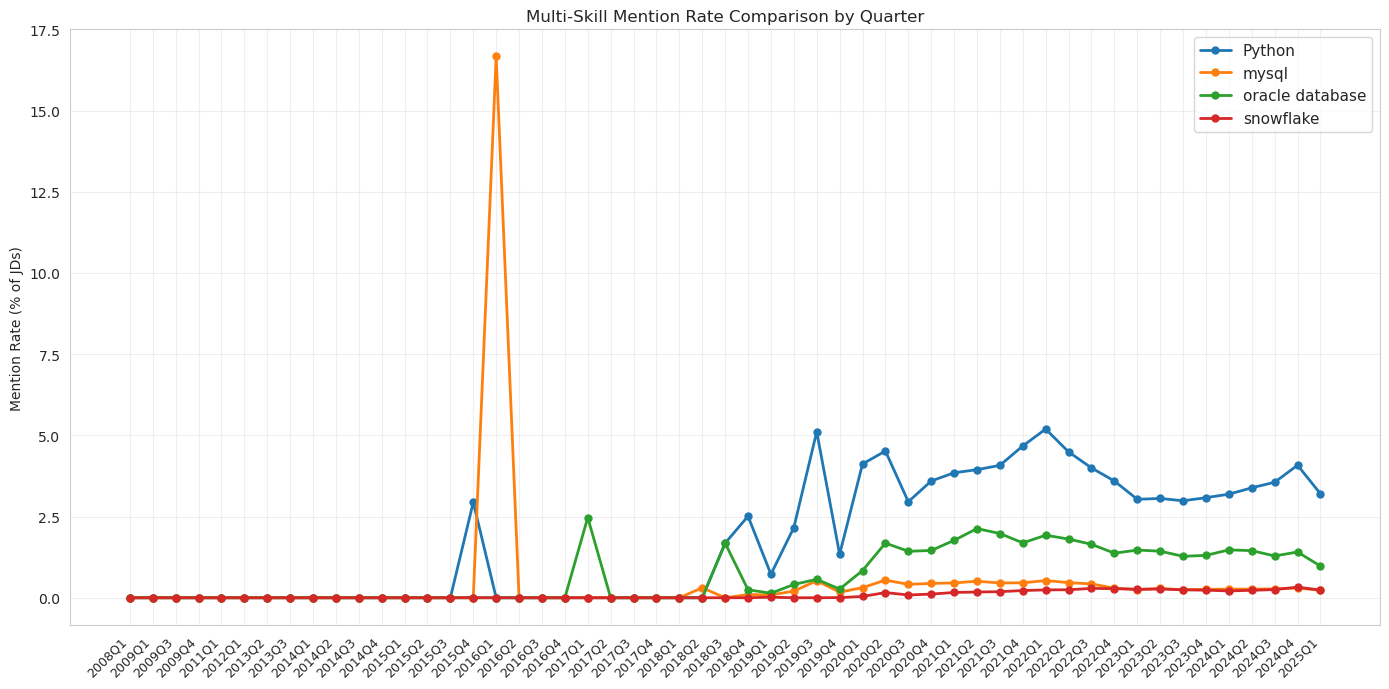

Quarter             Python         mysqloracle database     snowflake
---------------------------------------------------------------------
2008Q1               0.00%         0.00%         0.00%         0.00%
2009Q1               0.00%         0.00%         0.00%         0.00%
2009Q3               0.00%         0.00%         0.00%         0.00%
2009Q4               0.00%         0.00%         0.00%         0.00%
2011Q1               0.00%         0.00%         0.00%         0.00%
2012Q1               0.00%         0.00%         0.00%         0.00%
2013Q2               0.00%         0.00%         0.00%         0.00%
2013Q3               0.00%         0.00%         0.00%         0.00%
2014Q1               0.00%         0.00%         0.00%         0.00%
2014Q2               0.00%         0.00%         0.00%         0.00%
2014Q3               0.00%         0.00%         0.00%         0.00%
2014Q4               0.00%         0.00%         0.00%         0.00%
2015Q1               0.00%      

In [59]:
# =============================================================================
# MULTI-SKILL TREND - Edit the list below
# =============================================================================
TARGET_SKILLS = ['Python', 'mysql', 'oracle database', 'snowflake']  # <-- Change these
# =============================================================================

from collections import defaultdict

# skill -> quarter -> {'total': N, 'with_skill': N}
multi_quarterly = {skill: defaultdict(lambda: {'total': 0, 'with_skill': 0})
                   for skill in TARGET_SKILLS}

print(f"Tracking {len(TARGET_SKILLS)} skills: {TARGET_SKILLS}")
print(f"Scanning {len(parquet_files)} files...\n")

for i, filepath in enumerate(parquet_files):
    if (i + 1) % 30 == 0:
        print(f"  [{i+1}/{len(parquet_files)}]")

    try:
        df = pd.read_parquet(filepath, columns=[DATE_COLUMN, SKILLS_COLUMN])
    except Exception:
        continue

    df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors='coerce')
    df['quarter'] = df[DATE_COLUMN].dt.to_period('Q')

    for _, row in df.iterrows():
        q = row['quarter']
        if pd.isna(q):
            continue
        q_str = str(q)

        skills = parse_skills_column(row.get(SKILLS_COLUMN))
        skills_set = set(s.lower() for s in skills)  # case-insensitive lookup

        for target in TARGET_SKILLS:
            multi_quarterly[target][q_str]['total'] += 1
            if target.lower() in skills_set:
                multi_quarterly[target][q_str]['with_skill'] += 1


# Collect all quarters across all skills
all_quarters = set()
for skill_data in multi_quarterly.values():
    all_quarters.update(skill_data.keys())
quarters = sorted(all_quarters)

print(f"✓ Done. Found data for {len(quarters)} quarters.\n")

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.tab10.colors

for idx, skill in enumerate(TARGET_SKILLS):
    rates = []
    for q in quarters:
        d = multi_quarterly[skill][q]
        rate = (d['with_skill'] / d['total'] * 100) if d['total'] > 0 else 0
        rates.append(rate)

    ax.plot(range(len(quarters)), rates, marker='o', linewidth=2,
            markersize=5, color=colors[idx % len(colors)], label=skill)

ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mention Rate (% of JDs)')
ax.set_title('Multi-Skill Mention Rate Comparison by Quarter')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()

# Print table
header = f"{'Quarter':<12}" + "".join(f"{s:>14}" for s in TARGET_SKILLS)
print(header)
print("-" * len(header))
for q in quarters:
    row_str = f"{q:<12}"
    for skill in TARGET_SKILLS:
        d = multi_quarterly[skill][q]
        rate = (d['with_skill'] / d['total'] * 100) if d['total'] > 0 else 0
        row_str += f"{rate:>13.2f}%"
    print(row_str)

## Step 11: AI Impact Dimension Analysis

Analyze extracted skills by their AI Impact Dimension:
- **Replaced by AI**: Skills/tasks that AI can fully automate
- **Augmented by AI**: Skills enhanced by AI tools but requiring human judgment
- **Building/Managing AI**: Skills for developing, deploying, and managing AI systems
- **Resistant to AI**: Skills that are difficult for AI to replicate
- **Transformed by AI**: Skills fundamentally changed by AI capabilities

In [60]:
# Load AI Impact Dimensions lookup
from pathlib import Path

AI_IMPACT_LOOKUP_PATH = Path('../skillner/data/ksao_ai_impact_lookup.json')

if AI_IMPACT_LOOKUP_PATH.exists():
    with open(AI_IMPACT_LOOKUP_PATH) as f:
        AI_IMPACT_LOOKUP = json.load(f)
    print(f"✓ Loaded AI Impact lookup with {len(AI_IMPACT_LOOKUP):,} KSAOs")
    
    # Show dimension distribution in lookup
    dimension_counts = Counter(v['ai_impact_dimension'] for v in AI_IMPACT_LOOKUP.values())
    print(f"\nKSAOs by AI Impact Dimension:")
    for dim, count in dimension_counts.most_common():
        print(f"  {dim}: {count:,}")
else:
    print(f"⚠️ AI Impact lookup not found at: {AI_IMPACT_LOOKUP_PATH}")
    print("Please ensure the ksao_ai_impact_lookup.json file exists.")
    AI_IMPACT_LOOKUP = {}

✓ Loaded AI Impact lookup with 3,003 KSAOs

KSAOs by AI Impact Dimension:
  Transformed by AI: 1,674
  Replaced by AI: 618
  Building/Managing AI: 343
  Augmented by AI: 324
  Resistant to AI: 44


In [61]:
# Map all extracted skills to AI Impact Dimensions 
# Process files one at a time to avoid OOM crash
print("Analyzing AI Impact Dimensions across all files...")

if AI_IMPACT_LOOKUP:
    # Count skills by AI Impact Dimension
    ai_impact_skill_counts = {
        'Replaced by AI': Counter(),
        'Augmented by AI': Counter(),
        'Building/Managing AI': Counter(),
        'Resistant to AI': Counter(),
        'Transformed by AI': Counter(),
        'Unknown': Counter()
    }

    # Total mentions by dimension
    ai_impact_totals = Counter()
    matched_count = 0
    unmatched_count = 0
    unmatched_skills = set()

    for i, filepath in enumerate(parquet_files):
        try:
            df_part = pd.read_parquet(filepath, columns=[SKILLS_COLUMN])
        except Exception as e:
            print(f"  Skipping {filepath.name}: {e}")
            continue

        if SKILLS_COLUMN in df_part.columns:
            for skills_raw in df_part[SKILLS_COLUMN]:
                skills_list = parse_skills_column(skills_raw)
                for skill in skills_list:
                    skill_lower = skill.lower().strip()
                    if skill_lower in AI_IMPACT_LOOKUP:
                        dim = AI_IMPACT_LOOKUP[skill_lower]['ai_impact_dimension']
                        ai_impact_skill_counts[dim][skill] += 1
                        ai_impact_totals[dim] += 1
                        matched_count += 1
                    else:
                        ai_impact_skill_counts['Unknown'][skill] += 1
                        ai_impact_totals['Unknown'] += 1
                        unmatched_count += 1
                        unmatched_skills.add(skill)


        if (i + 1) % 10 == 0:
            print(f"  [{i+1}/{len(parquet_files)}] processed")

    total_mentions = matched_count + unmatched_count

    print(f"\n✓ Processed {len(parquet_files)} files.")
    print("="*70)
    print("SKILLS BY AI IMPACT DIMENSION")
    print("="*70)
    print(f"\nTotal skill mentions: {total_mentions:,}")
    if total_mentions > 0:
        print(f"Matched to AI Impact: {matched_count:,} ({matched_count/total_mentions*100:.1f}%)")
        print(f"Unmatched: {unmatched_count:,} ({unmatched_count/total_mentions*100:.1f}%)")

    print(f"\n{'AI Impact Dimension':<25} {'Mentions':<12} {'% of Total':<12} {'Unique Skills'}")
    print("-" * 70)

    for dim in ['Replaced by AI', 'Augmented by AI', 'Building/Managing AI',
                'Resistant to AI', 'Transformed by AI', 'Unknown']:
        count = ai_impact_totals[dim]
        unique = len(ai_impact_skill_counts[dim])
        pct = (count / total_mentions) * 100 if total_mentions > 0 else 0
        print(f"{dim:<25} {count:<12,} {pct:<12.1f} {unique:,}")

    print(f"\nTop 10 'Unknown' skills (not in AI Impact lookup):")
    for skill, count in ai_impact_skill_counts['Unknown'].most_common(10):
        print(f"  - {skill}: {count:,}")
else:
    print("⚠️ Cannot perform AI Impact analysis: missing AI Impact lookup")

Analyzing AI Impact Dimensions across all files...
  [10/279] processed
  [20/279] processed
  [30/279] processed
  [40/279] processed
  [50/279] processed
  [60/279] processed
  [70/279] processed
  [80/279] processed
  [90/279] processed
  [100/279] processed
  [110/279] processed
  [120/279] processed
  [130/279] processed
  [140/279] processed
  [150/279] processed
  [160/279] processed
  [170/279] processed
  [180/279] processed
  [190/279] processed
  [200/279] processed
  [210/279] processed
  [220/279] processed
  [230/279] processed
  [240/279] processed
  [250/279] processed
  [260/279] processed
  [270/279] processed

✓ Processed 279 files.
SKILLS BY AI IMPACT DIMENSION

Total skill mentions: 184,736,336
Matched to AI Impact: 184,736,336 (100.0%)
Unmatched: 0 (0.0%)

AI Impact Dimension       Mentions     % of Total   Unique Skills
----------------------------------------------------------------------
Replaced by AI            38,967,112   21.1         515
Augmented by AI   

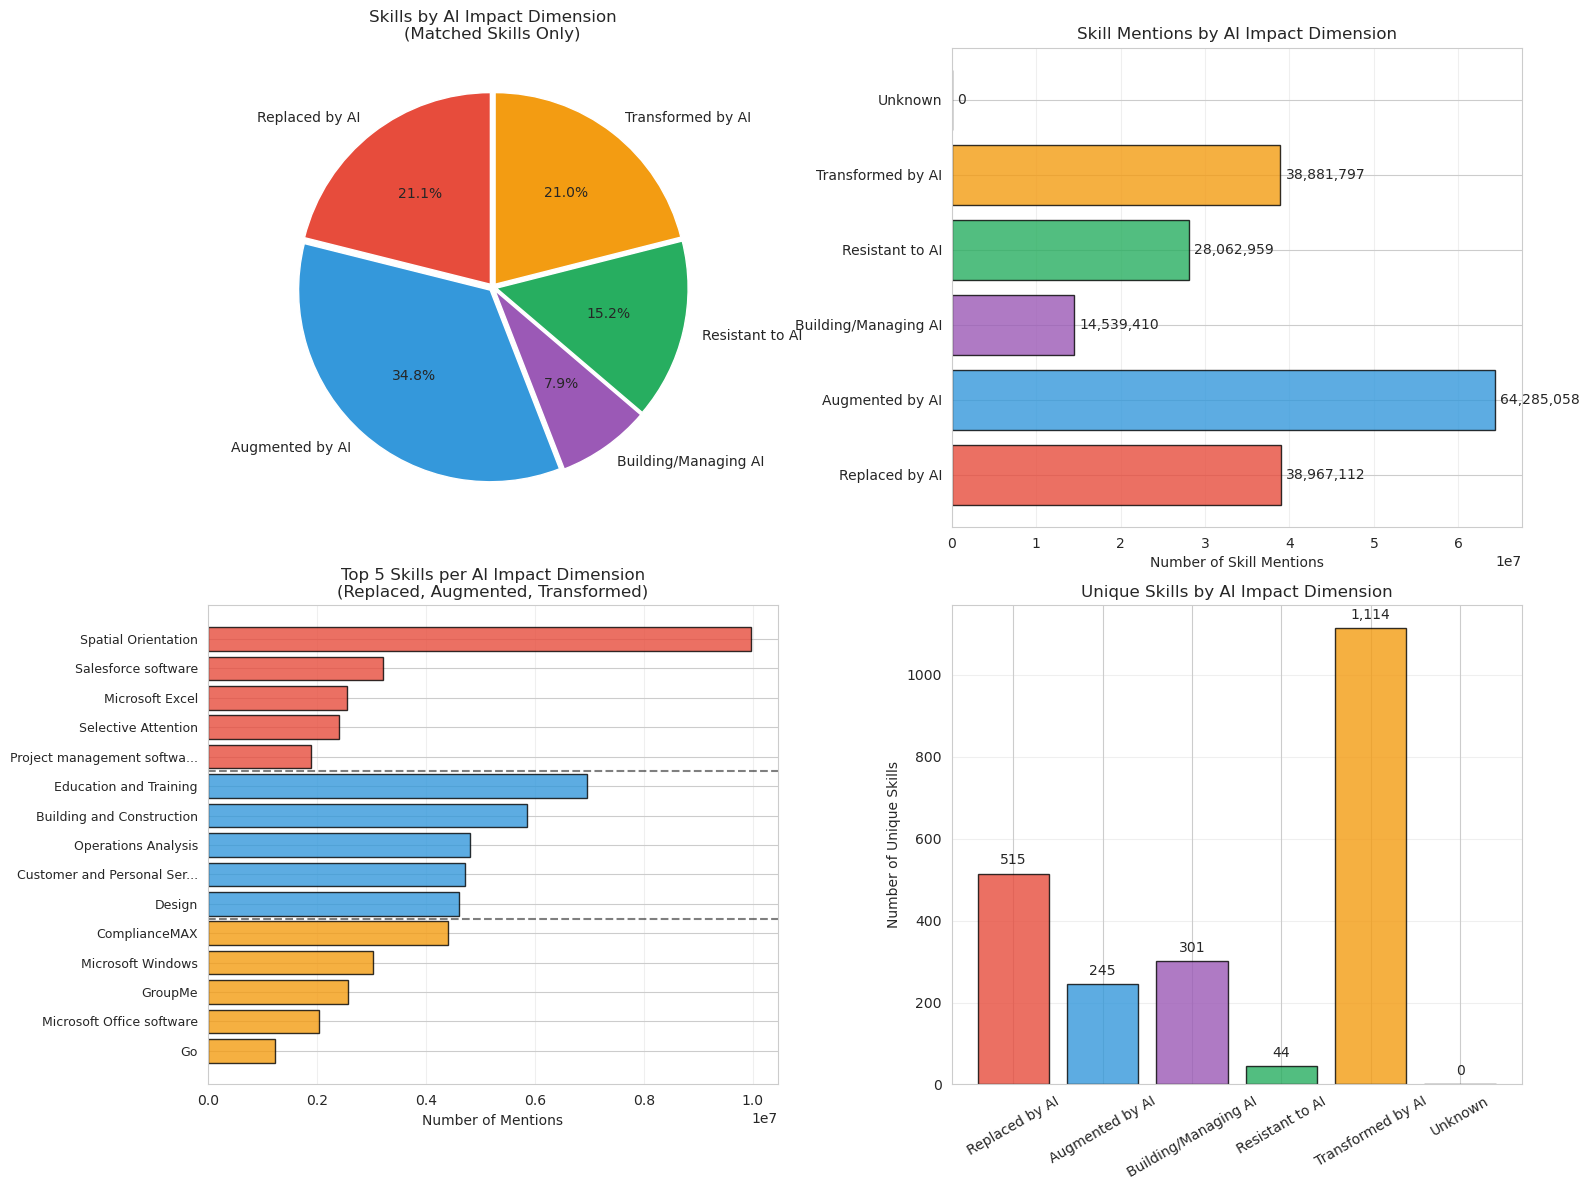

In [62]:
# Visualize AI Impact Dimension distribution
if AI_IMPACT_LOOKUP and ai_impact_totals:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Define colors for each dimension
    dim_colors = {
        'Replaced by AI': '#e74c3c',      # Red
        'Augmented by AI': '#3498db',     # Blue
        'Building/Managing AI': '#9b59b6', # Purple
        'Resistant to AI': '#27ae60',     # Green
        'Transformed by AI': '#f39c12',   # Orange
        'Unknown': '#95a5a6'              # Gray
    }
    
    # 1. Pie chart of AI Impact Dimensions (excluding Unknown)
    dims_for_pie = ['Replaced by AI', 'Augmented by AI', 'Building/Managing AI', 
                    'Resistant to AI', 'Transformed by AI']
    pie_values = [ai_impact_totals[d] for d in dims_for_pie]
    pie_colors = [dim_colors[d] for d in dims_for_pie]
    
    axes[0, 0].pie(pie_values, labels=dims_for_pie, colors=pie_colors, 
                   autopct='%1.1f%%', startangle=90, explode=[0.02]*5)
    axes[0, 0].set_title('Skills by AI Impact Dimension\n(Matched Skills Only)', fontsize=12)
    
    # 2. Bar chart of all dimensions including Unknown
    all_dims = ['Replaced by AI', 'Augmented by AI', 'Building/Managing AI', 
                'Resistant to AI', 'Transformed by AI', 'Unknown']
    bar_values = [ai_impact_totals[d] for d in all_dims]
    bar_colors = [dim_colors[d] for d in all_dims]
    
    bars = axes[0, 1].barh(all_dims, bar_values, color=bar_colors, edgecolor='black', alpha=0.8)
    axes[0, 1].set_xlabel('Number of Skill Mentions')
    axes[0, 1].set_title('Skill Mentions by AI Impact Dimension', fontsize=12)
    axes[0, 1].grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, bar_values):
        axes[0, 1].text(val + max(bar_values)*0.01, bar.get_y() + bar.get_height()/2, 
                       f'{val:,}', va='center', fontsize=10)
    
    # 3. Top skills per dimension (select 3 dimensions)
    dims_to_show = ['Replaced by AI', 'Augmented by AI', 'Transformed by AI']
    top_per_dim = []
    labels = []
    colors = []
    
    for dim in dims_to_show:
        top_5 = ai_impact_skill_counts[dim].most_common(5)
        for skill, count in top_5:
            top_per_dim.append(count)
            labels.append(f"{skill[:25]}..." if len(skill) > 25 else skill)
            colors.append(dim_colors[dim])
    
    y_pos = range(len(labels))
    axes[1, 0].barh(y_pos, top_per_dim, color=colors, edgecolor='black', alpha=0.8)
    axes[1, 0].set_yticks(y_pos)
    axes[1, 0].set_yticklabels(labels, fontsize=9)
    axes[1, 0].set_xlabel('Number of Mentions')
    axes[1, 0].set_title('Top 5 Skills per AI Impact Dimension\n(Replaced, Augmented, Transformed)', fontsize=12)
    axes[1, 0].grid(axis='x', alpha=0.3)
    axes[1, 0].invert_yaxis()
    
    # Add horizontal lines to separate dimensions
    axes[1, 0].axhline(y=4.5, color='black', linestyle='--', alpha=0.5)
    axes[1, 0].axhline(y=9.5, color='black', linestyle='--', alpha=0.5)
    
    # 4. Unique skills count per dimension
    unique_counts = [len(ai_impact_skill_counts[d]) for d in all_dims]
    axes[1, 1].bar(all_dims, unique_counts, color=bar_colors, edgecolor='black', alpha=0.8)
    axes[1, 1].set_ylabel('Number of Unique Skills')
    axes[1, 1].set_title('Unique Skills by AI Impact Dimension', fontsize=12)
    axes[1, 1].tick_params(axis='x', rotation=30)
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    for i, (dim, count) in enumerate(zip(all_dims, unique_counts)):
        axes[1, 1].text(i, count + max(unique_counts)*0.02, f'{count:,}', 
                       ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [63]:
# Time series analysis: AI Impact Dimensions over time (memory-efficient)
if AI_IMPACT_LOOKUP:
    print("="*70)
    print("AI IMPACT DIMENSIONS OVER TIME")
    print("="*70)

    from collections import defaultdict

    # quarter -> {dimension -> count, '__total__' -> count}
    quarterly_dim_counts = defaultdict(lambda: {
        'Replaced by AI': 0, 'Augmented by AI': 0, 'Building/Managing AI': 0,
        'Resistant to AI': 0, 'Transformed by AI': 0, '__jd_count__': 0
    })

    print("Scanning files for quarterly AI Impact trends...")

    for i, filepath in enumerate(parquet_files):
        try:
            df_part = pd.read_parquet(filepath, columns=[DATE_COLUMN, SKILLS_COLUMN])
        except Exception:
            continue

        df_part[DATE_COLUMN] = pd.to_datetime(df_part[DATE_COLUMN], errors='coerce')
        df_part['quarter'] = df_part[DATE_COLUMN].dt.to_period('Q')

        for _, row in df_part.iterrows():
            q = row['quarter']
            if pd.isna(q):
                continue
            q_str = str(q)
            quarterly_dim_counts[q_str]['__jd_count__'] += 1

            skills_list = parse_skills_column(row.get(SKILLS_COLUMN))
            for skill in skills_list:
                skill_lower = skill.lower().strip()
                if skill_lower in AI_IMPACT_LOOKUP:
                    dim = AI_IMPACT_LOOKUP[skill_lower]['ai_impact_dimension']
                    if dim in quarterly_dim_counts[q_str]:
                        quarterly_dim_counts[q_str][dim] += 1

        del df_part
        gc.collect()
        if (i + 1) % 10 == 0:
            print(f"  [{i+1}/{len(parquet_files)}] processed")

    # Build quarterly_ai DataFrame for visualization in cell 32
    quarters_sorted = sorted(quarterly_dim_counts.keys())
    dim_names = ['Replaced by AI', 'Augmented by AI', 'Building/Managing AI',
                 'Resistant to AI', 'Transformed by AI']
    ai_col_names = [f'ai_{d.replace(" ", "_").replace("/", "_").lower()}' for d in dim_names]

    quarterly_ai_rows = []
    for q in quarters_sorted:
        jd_count = quarterly_dim_counts[q]['__jd_count__']
        if jd_count == 0:
            continue
        row_data = {'year_quarter': q}
        for dim, col_name in zip(dim_names, ai_col_names):
            row_data[col_name] = quarterly_dim_counts[q][dim] / jd_count
        quarterly_ai_rows.append(row_data)

    quarterly_ai = pd.DataFrame(quarterly_ai_rows)

    print(f"\n✓ Done. {len(quarterly_ai)} quarters analyzed.")
    print(f"\nAverage skills per JD by AI Impact Dimension (quarterly):")
    print(quarterly_ai.tail(10).to_string(index=False))
else:
    print("⚠️ Cannot perform time series analysis: missing AI Impact lookup")

AI IMPACT DIMENSIONS OVER TIME
Scanning files for quarterly AI Impact trends...
  [10/279] processed
  [20/279] processed
  [30/279] processed
  [40/279] processed
  [50/279] processed
  [60/279] processed
  [70/279] processed
  [80/279] processed
  [90/279] processed
  [100/279] processed
  [110/279] processed
  [120/279] processed
  [130/279] processed
  [140/279] processed
  [150/279] processed
  [160/279] processed
  [170/279] processed
  [180/279] processed
  [190/279] processed
  [200/279] processed
  [210/279] processed
  [220/279] processed
  [230/279] processed
  [240/279] processed
  [250/279] processed
  [260/279] processed
  [270/279] processed

✓ Done. 53 quarters analyzed.

Average skills per JD by AI Impact Dimension (quarterly):
year_quarter  ai_replaced_by_ai  ai_augmented_by_ai  ai_building_managing_ai  ai_resistant_to_ai  ai_transformed_by_ai
      2022Q4           1.823507            2.979076                 0.659135            1.296399              1.744933
      2

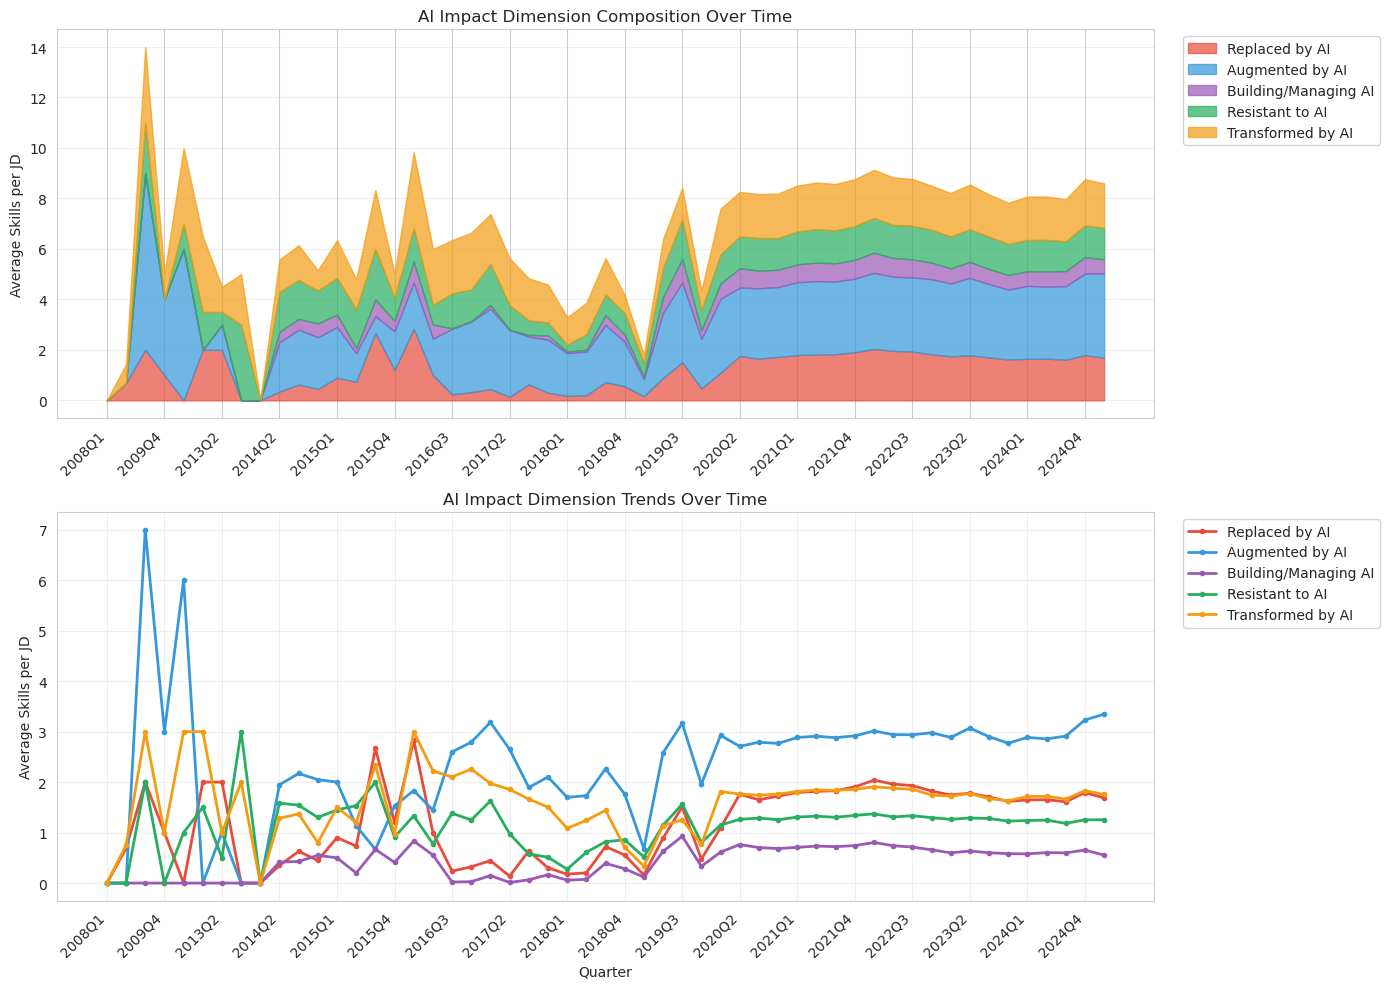


Summary: Change from first to last quarter
------------------------------------------------------------
Replaced by AI           : 0.69 → 1.69 (↑ 145.5%)
Augmented by AI          : 0.00 → 3.34 (→ 0.0%)
Building/Managing AI     : 0.00 → 0.55 (→ 0.0%)
Resistant to AI          : 0.00 → 1.25 (→ 0.0%)
Transformed by AI        : 0.75 → 1.76 (↑ 134.3%)


In [64]:
# Visualize AI Impact Dimensions over time
if 'quarterly_ai' in dir() and len(quarterly_ai) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot columns and labels
    dim_mapping = {
        'ai_replaced_by_ai': ('Replaced by AI', '#e74c3c'),
        'ai_augmented_by_ai': ('Augmented by AI', '#3498db'),
        'ai_building_managing_ai': ('Building/Managing AI', '#9b59b6'),
        'ai_resistant_to_ai': ('Resistant to AI', '#27ae60'),
        'ai_transformed_by_ai': ('Transformed by AI', '#f39c12')
    }
    
    x_labels = [str(q) for q in quarterly_ai['year_quarter']]
    
    # 1. Stacked area chart showing composition over time
    ax1 = axes[0]
    bottom = np.zeros(len(quarterly_ai))
    
    for col, (label, color) in dim_mapping.items():
        if col in quarterly_ai.columns:
            values = quarterly_ai[col].values
            ax1.fill_between(range(len(x_labels)), bottom, bottom + values, 
                           label=label, color=color, alpha=0.7)
            bottom = bottom + values
    
    ax1.set_xticks(range(0, len(x_labels), max(1, len(x_labels)//15)))
    ax1.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), max(1, len(x_labels)//15))], 
                       rotation=45, ha='right')
    ax1.set_ylabel('Average Skills per JD')
    ax1.set_title('AI Impact Dimension Composition Over Time', fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Line chart showing trends for each dimension
    ax2 = axes[1]
    
    for col, (label, color) in dim_mapping.items():
        if col in quarterly_ai.columns:
            ax2.plot(range(len(x_labels)), quarterly_ai[col].values, 
                    label=label, color=color, linewidth=2, marker='o', markersize=3)
    
    ax2.set_xticks(range(0, len(x_labels), max(1, len(x_labels)//15)))
    ax2.set_xticklabels([x_labels[i] for i in range(0, len(x_labels), max(1, len(x_labels)//15))], 
                       rotation=45, ha='right')
    ax2.set_xlabel('Quarter')
    ax2.set_ylabel('Average Skills per JD')
    ax2.set_title('AI Impact Dimension Trends Over Time', fontsize=12)
    ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary: Change from first to last quarter")
    print("-" * 60)
    for col, (label, _) in dim_mapping.items():
        if col in quarterly_ai.columns:
            first_val = quarterly_ai[col].iloc[1]
            last_val = quarterly_ai[col].iloc[-1]
            change = ((last_val - first_val) / first_val * 100) if first_val > 0 else 0
            trend = "↑" if change > 0 else "↓" if change < 0 else "→"
            print(f"{label:<25}: {first_val:.2f} → {last_val:.2f} ({trend} {abs(change):.1f}%)")

In [67]:
# AI Impact Analysis by ONET Code: Which occupations are most at risk? (memory-efficient)
if AI_IMPACT_LOOKUP:
    print("="*70)
    print("AI IMPACT RISK BY ONET OCCUPATION CODE")
    print("="*70)

    from collections import defaultdict

    # onet_code -> {dimension -> count, '__total__' -> count, '__jd_count__' -> count}
    onet_dim_data = defaultdict(lambda: {
        'Replaced by AI': 0, 'Augmented by AI': 0, 'Building/Managing AI': 0,
        'Resistant to AI': 0, 'Transformed by AI': 0, '__total__': 0, '__jd_count__': 0
    })

    print("Scanning files for ONET AI Impact profiles...")

    for i, filepath in enumerate(parquet_files):
        try:
            df_part = pd.read_parquet(filepath, columns=[ONET_CODE_COLUMN, SKILLS_COLUMN])
        except Exception:
            continue

        if ONET_CODE_COLUMN in df_part.columns and SKILLS_COLUMN in df_part.columns:
            for _, row in df_part.iterrows():
                onet_code = row.get(ONET_CODE_COLUMN)
                if pd.isna(onet_code):
                    continue
                onet_dim_data[onet_code]['__jd_count__'] += 1

                skills_list = parse_skills_column(row.get(SKILLS_COLUMN))
                for skill in skills_list:
                    skill_lower = skill.lower().strip()
                    if skill_lower in AI_IMPACT_LOOKUP:
                        dim = AI_IMPACT_LOOKUP[skill_lower]['ai_impact_dimension']
                        if dim in onet_dim_data[onet_code]:
                            onet_dim_data[onet_code][dim] += 1
                            onet_dim_data[onet_code]['__total__'] += 1

        del df_part
        gc.collect()
        if (i + 1) % 10 == 0:
            print(f"  [{i+1}/{len(parquet_files)}] processed")

    # Build profiles for top 50 ONET codes by JD count
    onet_jd_counts = {code: data['__jd_count__'] for code, data in onet_dim_data.items()}
    top_50_codes = sorted(onet_jd_counts, key=onet_jd_counts.get, reverse=True)[:50]

    onet_ai_profiles = []
    for onet_code in top_50_codes:
        data = onet_dim_data[onet_code]
        total_skills = data['__total__']
        if total_skills > 0:
            profile = {
                'onet_code': onet_code,
                'jd_count': data['__jd_count__'],
                'total_skills': total_skills,
                'pct_replaced': data['Replaced by AI'] / total_skills * 100,
                'pct_augmented': data['Augmented by AI'] / total_skills * 100,
                'pct_building': data['Building/Managing AI'] / total_skills * 100,
                'pct_resistant': data['Resistant to AI'] / total_skills * 100,
                'pct_transformed': data['Transformed by AI'] / total_skills * 100,
            }
            profile['ai_risk_score'] = profile['pct_replaced'] + 0.5 * profile['pct_transformed']
            onet_ai_profiles.append(profile)

    onet_ai_df = pd.DataFrame(onet_ai_profiles)
    onet_ai_df = onet_ai_df.sort_values('ai_risk_score', ascending=False)

    print(f"\n✓ Analyzed {len(onet_dim_data)} unique ONET codes.")
    print("\nTop 15 ONET codes with highest AI replacement risk:")
    print("-" * 90)
    print(f"{'ONET Code':<15} {'JDs':>8} {'Replaced%':>10} {'Augmented%':>10} {'Build/Mgmt%':>10} {'Risk Score':>12}")
    print("-" * 90)

    for _, row in onet_ai_df.head(15).iterrows():
        print(f"{row['onet_code']:<15} {row['jd_count']:>8,} {row['pct_replaced']:>10.1f} "
              f"{row['pct_augmented']:>10.1f} {row['pct_building']:>10.1f} {row['ai_risk_score']:>12.1f}")

    print("\n\nTop 10 ONET codes with LOWEST AI replacement risk (most resistant):")
    print("-" * 90)
    for _, row in onet_ai_df.tail(10).iterrows():
        print(f"{row['onet_code']:<15} {row['jd_count']:>8,} {row['pct_replaced']:>10.1f} "
              f"{row['pct_augmented']:>10.1f} {row['pct_resistant']:>10.1f} {row['ai_risk_score']:>12.1f}")
else:
    print("⚠️ Cannot perform ONET AI Impact analysis: missing AI Impact lookup")

AI IMPACT RISK BY ONET OCCUPATION CODE
Scanning files for ONET AI Impact profiles...
  [10/279] processed
  [20/279] processed
  [30/279] processed
  [40/279] processed
  [50/279] processed
  [60/279] processed
  [70/279] processed
  [80/279] processed
  [90/279] processed
  [100/279] processed
  [110/279] processed
  [120/279] processed
  [130/279] processed
  [140/279] processed
  [150/279] processed
  [160/279] processed
  [170/279] processed
  [180/279] processed
  [190/279] processed
  [200/279] processed
  [210/279] processed
  [220/279] processed
  [230/279] processed
  [240/279] processed
  [250/279] processed
  [260/279] processed
  [270/279] processed

✓ Analyzed 384 unique ONET codes.

Top 15 ONET codes with highest AI replacement risk:
------------------------------------------------------------------------------------------
ONET Code            JDs  Replaced% Augmented% Build/Mgmt%   Risk Score
-------------------------------------------------------------------------------

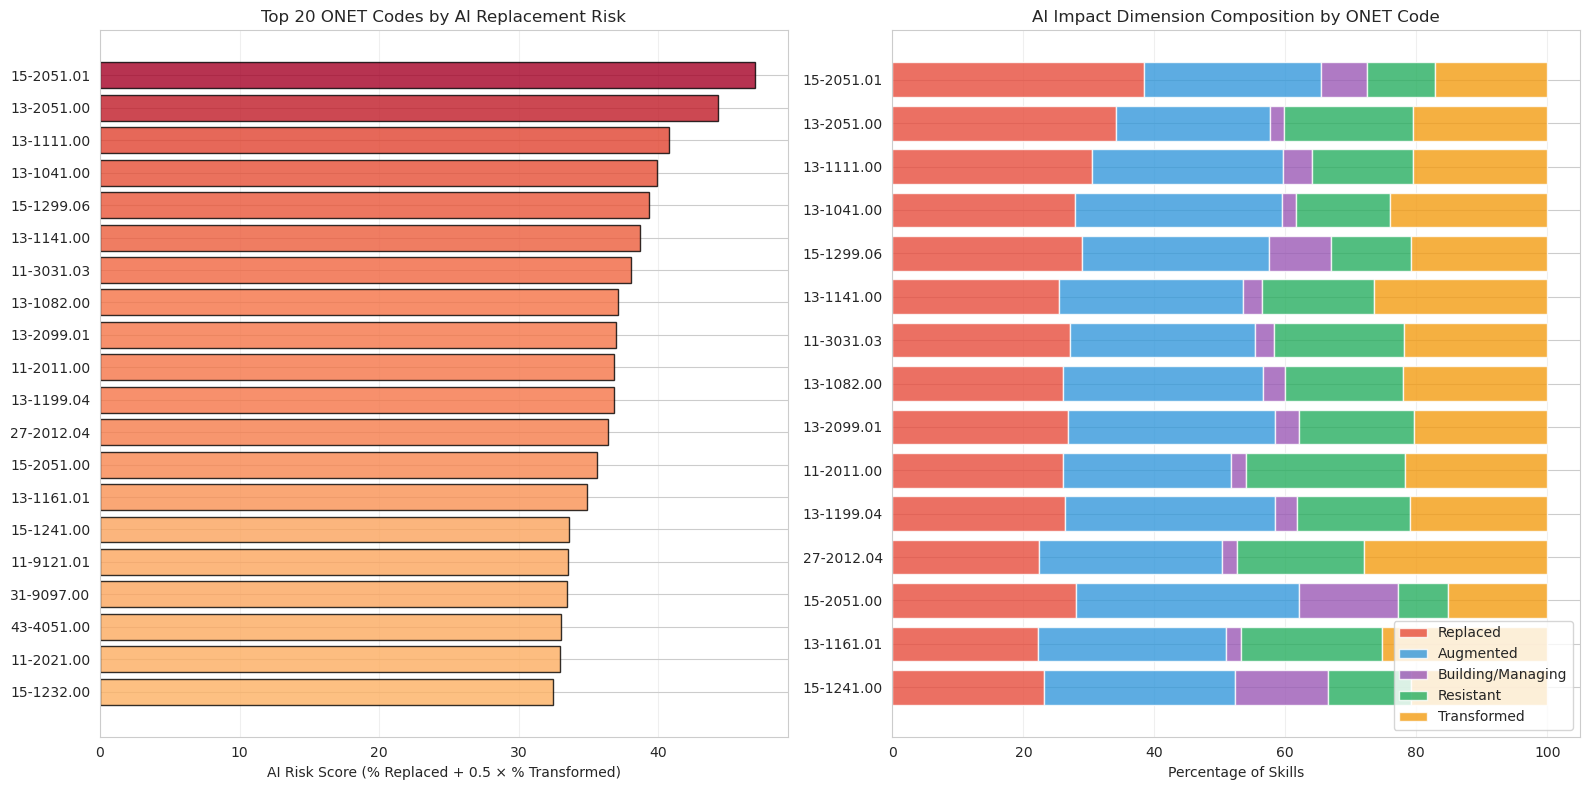

In [68]:
# Visualize AI Impact by ONET Code
if 'onet_ai_df' in dir() and len(onet_ai_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 1. Horizontal bar chart: AI Risk Score by ONET code (top 20)
    top_20_risk = onet_ai_df.head(20)
    
    colors = plt.cm.RdYlGn_r(top_20_risk['ai_risk_score'] / top_20_risk['ai_risk_score'].max())
    
    axes[0].barh(range(len(top_20_risk)), top_20_risk['ai_risk_score'], 
                color=colors, edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(len(top_20_risk)))
    axes[0].set_yticklabels(top_20_risk['onet_code'])
    axes[0].set_xlabel('AI Risk Score (% Replaced + 0.5 × % Transformed)')
    axes[0].set_title('Top 20 ONET Codes by AI Replacement Risk', fontsize=12)
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()
    
    # 2. Stacked bar showing composition for top 15 codes
    top_15 = onet_ai_df.head(15)
    
    dims = ['pct_replaced', 'pct_augmented', 'pct_building', 'pct_resistant', 'pct_transformed']
    dim_labels = ['Replaced', 'Augmented', 'Building/Managing', 'Resistant', 'Transformed']
    dim_colors = ['#e74c3c', '#3498db', '#9b59b6', '#27ae60', '#f39c12']
    
    left = np.zeros(len(top_15))
    for dim, label, color in zip(dims, dim_labels, dim_colors):
        axes[1].barh(range(len(top_15)), top_15[dim], left=left, 
                    label=label, color=color, alpha=0.8)
        left += top_15[dim].values
    
    axes[1].set_yticks(range(len(top_15)))
    axes[1].set_yticklabels(top_15['onet_code'])
    axes[1].set_xlabel('Percentage of Skills')
    axes[1].set_title('AI Impact Dimension Composition by ONET Code', fontsize=12)
    axes[1].legend(loc='lower right')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

## Step 12: Top ONET Codes

In [34]:
print("="*70)
print("TOP ONET CODES")
print("="*70)

onet_counts = merged['onet_counts']

if onet_counts:
    top_onet = onet_counts.most_common(15)
    
    print(f"\n{'ONET Code':<20}{'Count':>10}{'% of Total':>12}")
    print("-"*42)
    
    for onet_code, count in top_onet:
        pct = (count / merged['total_rows']) * 100 if merged['total_rows'] > 0 else 0
        print(f"{onet_code:<20}{count:>10,}{pct:>11.1f}%")
else:
    print("\n[INFO] No ONET code data available")

TOP ONET CODES

ONET Code                Count  % of Total
------------------------------------------
41-1011.00           1,043,656        4.8%
51-9198.00             581,640        2.7%
15-1252.00             549,368        2.5%
53-7065.00             487,621        2.2%
13-2051.00             448,615        2.0%
11-2011.00             426,318        1.9%
15-1241.00             409,741        1.9%
35-3041.00             407,313        1.9%
43-4051.00             382,804        1.7%
13-1111.00             379,253        1.7%
41-4011.00             353,150        1.6%
53-6021.00             315,273        1.4%
11-2021.00             297,859        1.4%
41-2031.00             264,386        1.2%
15-1299.07             244,290        1.1%


## Step 12: Save Summary

In [35]:
summary_path = Path(INPUT_FOLDER) / 'analysis_summary.json'

summary = {
    'total_files': merged['total_files'],
    'total_jds': merged['total_rows'],
    'jds_with_skills': merged['jds_with_skills'],
    'jds_without_skills': merged['jds_without_skills'],
    'unique_skills': len(merged['skill_counter']) if merged.get('skill_counter') else 0,
    'top_30_skills': [(s, c) for s, c in merged['skill_counter'].most_common(30)] if merged.get('skill_counter') else [],
    'skills_by_section': dict(merged['section_counts']) if merged.get('section_counts') else {},
}

with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✓ Summary saved to: {summary_path}")

✓ Summary saved to: ../data/extracted_skills_production/analysis_summary.json


## Done!

Analysis complete. Check the output above for results.